## Step 1: Load the Dataset

We load `zeroshot/twitter-financial-news-topic` from the Hugging Face Hub using
`load_dataset()`. This returns a `DatasetDict` — a dictionary of splits (`train`,
`validation`), where each split is a memory-mapped `Dataset` object with columns
`text` and `label`.

The dataset is cached locally after the first download, so re-running this cell
won't re-download. The printed structure tells us split names, row counts, and
columns — our first sanity check that the data loaded correctly.

In [1]:
!pip install -q datasets
from datasets import load_dataset

dataset = load_dataset("zeroshot/twitter-financial-news-topic")
print(dataset)

README.md: 0.00B [00:00, ?B/s]

topic_train.csv: 0.00B [00:00, ?B/s]

topic_valid.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/16990 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/4117 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16990
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 4117
    })
})


### Peek at a Single Example

Before doing anything else, let's look at one raw example to understand the
data's shape: what does a single row actually look like? This tells us the
`text` field holds the raw tweet content, and `label` holds an integer — which
raises the immediate next question: what do these integers mean?

In [2]:
dataset["train"][0]

{'text': "Here are Thursday's biggest analyst calls: Apple, Amazon, Tesla, Palantir, DocuSign, Exxon &amp; more  https://t.co/QPN8Gwl7Uh",
 'label': 0}

## Step 2a: Inspect the Label Schema

Before exploring class balance, we need to know what the integer `label` values
actually mean. HF datasets sometimes encode labels as a `ClassLabel` type, which
carries the string names with it (accessible via `.features["label"].names`).
Other times labels are stored as plain integers (`Value('int64')`) with the
mapping documented separately in the dataset card instead of the schema.

Checking `.features` tells us which case we're in before we write any more code.

In [4]:
dataset["train"].features

{'text': Value('string'), 'label': Value('int64')}

Since `label` is a plain `Value('int64')`, attempting `.features["label"].names` would raise an `AttributeError` — there's no `.names` attribute on a `Value` type, only on `ClassLabel`. Rather than run a cell that just errors out, we take that as our signal to go find the mapping elsewhere: the dataset README.

## Step 2b: Manually Encode the Label Mapping

**How to find label names when a column isn't `ClassLabel` (reusable process):**

1. **Check `.features` first** — if it shows `ClassLabel(names=[...])`, use `.names` directly.
2. **Read the dataset card (README)** on `huggingface.co/datasets/<dataset_name>` — authors often document label mappings there as a dict. This is where we found ours.
3. **Check for a metadata/config file** under "Files and versions" (e.g. `dataset_infos.json`).
4. **Check a fine-tuned model's config** — `id2label`/`label2id` in `config.json`, machine-readable.
5. **Last resort — infer from content** by manually reading examples per label integer.

**The habit:** if a label column is `Value('int64')`, stop and find the mapping before writing more code — don't guess. Getting it wrong silently won't error out, it'll just quietly produce a wrong model.

We hardcode the mapping here as an ordered list, where position `i` corresponds to integer label `i`. Because this isn't a `ClassLabel`, downstream we'll also need to pass `num_labels`, `id2label`, and `label2id` explicitly when loading the model — the `Trainer` won't infer these automatically the way it would with a proper `ClassLabel` column.

We then decode the first training example using this list as a sanity check that positions line up correctly.

In [5]:
label_names = [
    "Analyst Update",
    "Fed | Central Banks",
    "Company | Product News",
    "Treasuries | Corporate Debt",
    "Dividend",
    "Earnings",
    "Energy | Oil",
    "Financials",
    "Currencies",
    "General News | Opinion",
    "Gold | Metals | Materials",
    "IPO",
    "Legal | Regulation",
    "M&A | Investments",
    "Macro",
    "Markets",
    "Politics",
    "Personnel Change",
    "Stock Commentary",
    "Stock Movement",
]
print(len(label_names))  # sanity check: should be 20

20


In [6]:
print(label_names[dataset["train"][0]["label"]])

Analyst Update


## Fetching Label Info Programmatically (Reusable Pattern)

There's no universal function that reliably parses label names out of a
dataset automatically — `ClassLabel` is the only case with a guaranteed API
(`.features["label"].names`). For `Value('int64')` labels, the mapping lives
wherever the author put it (README, a metadata file, or only in a fine-tuned
model's config), written as prose or an ad hoc dict — nothing HF enforces a
schema for.

What we *can* automate is fetching that documentation into the notebook
instead of switching to a browser tab:

- `list_repo_files()` — see what files exist in the dataset repo
- `hf_hub_download()` — pull a specific file (e.g. `README.md`) locally to
  read in Python
- `load_dataset_builder()` — sometimes surfaces richer metadata
  (`builder.info.description`, `builder.info.features`) than the materialized
  dataset does

We still read the output and transcribe the mapping ourselves — this just
removes the need to leave the notebook to find it.

In [7]:
from huggingface_hub import list_repo_files

# See what files exist in the dataset repo
files = list_repo_files("zeroshot/twitter-financial-news-topic", repo_type="dataset")
print(files)

['.gitattributes', 'README.md', 'topic_dataset_meta.txt', 'topic_train.csv', 'topic_valid.csv']


In [8]:
from huggingface_hub import hf_hub_download

readme_path = hf_hub_download(
    repo_id="zeroshot/twitter-financial-news-topic",
    filename="README.md",
    repo_type="dataset"
)

print(open(readme_path).read())

---
annotations_creators:
- other
language:
- en
language_creators:
- other
license:
- mit
multilinguality:
- monolingual
pretty_name: twitter financial news
size_categories:
- 10K<n<100K
source_datasets:
- original
tags:
- twitter
- finance
- markets
- stocks
- wallstreet
- quant
- hedgefunds
- markets
task_categories:
- text-classification
task_ids:
- multi-class-classification
---

### Dataset Description

The Twitter Financial News dataset is an English-language dataset containing an annotated corpus of finance-related tweets. This dataset is used to classify finance-related tweets for their topic.

1. The dataset holds 21,107 documents annotated with 20 labels:

```python
topics = {
    "LABEL_0": "Analyst Update",
    "LABEL_1": "Fed | Central Banks",
    "LABEL_2": "Company | Product News",
    "LABEL_3": "Treasuries | Corporate Debt",
    "LABEL_4": "Dividend",
    "LABEL_5": "Earnings",
    "LABEL_6": "Energy | Oil",
    "LABEL_7": "Financials",
    "LABEL_8": "Currencies",
  

In [9]:
from datasets import load_dataset_builder

builder = load_dataset_builder("zeroshot/twitter-financial-news-topic")
print(builder.info.features)
print(builder.info.description)

{'text': Value('string'), 'label': Value('int64')}



## Step 2d: Class Balance

With 20 categories, it's unlikely every class is equally represented — financial
tweets naturally skew toward certain topics. This matters because:

- **Training dynamics:** a class with far fewer examples gets much less
  gradient signal, so the model may barely learn to recognize it.
- **Metric choice:** with imbalance, plain accuracy can be misleading (a model
  that never predicts a rare class can still score high accuracy). This is why
  we'll track *macro* F1 later alongside accuracy — macro F1 averages
  per-class F1 unweighted, so poor performance on rare classes isn't hidden.
- **Eval interpretation:** knowing the distribution up front helps later
  distinguish "this class is genuinely hard" from "this class barely had any
  training data" when we look at the confusion matrix.

We're only measuring imbalance here, not fixing it — that decision (e.g. class
weighting, or just reporting macro F1 honestly) comes after we see the numbers.

We pull the full `label` column as a plain list, count occurrences per class
with pandas, sort by label ID for readability, then swap the integer index for
human-readable names using `label_names`.

In [10]:
import pandas as pd

train_labels = dataset["train"]["label"]
label_counts = pd.Series(train_labels).value_counts().sort_index()

label_counts.index = [label_names[i] for i in label_counts.index]
print(label_counts)

Analyst Update                  255
Fed | Central Banks             837
Company | Product News         3545
Treasuries | Corporate Debt     321
Dividend                        359
Earnings                        987
Energy | Oil                    524
Financials                      624
Currencies                      166
General News | Opinion         1557
Gold | Metals | Materials        69
IPO                              44
Legal | Regulation              487
M&A | Investments               471
Macro                          1822
Markets                         501
Politics                        985
Personnel Change                495
Stock Commentary               2118
Stock Movement                  823
Name: count, dtype: int64


In [11]:
import random 

def show_examples(label_name, n=3):
    label_id = label_names.index(label_name)
    matches = [ex for ex in dataset["train"] if ex["label"] == label_id]
    for ex in random.sample(matches, n):
        print(ex["text"])
        print("---")


show_examples("IPO")

“We are certainly in a wait-and-see period,” EY Americas IPO Leader @RachelGerring says on IPOs. “Companies are pausing, taking stock of just what's happening across the broader market.”  https://t.co/zNRFBUB1aB
---
In 2021, “you had 400 traditional IPOs with 600 SPACs go public,” @WilliamBlair Managing Director @SteveMaletzky says. “Risk appetite was significantly high, and you had those IPOs transacting at elevated multiples.”  https://t.co/PhkTjCBEfr
---
$VWAGY - Volkswagen battery unit PowerCo reportedly ramping up production ahead of IPO  https://t.co/ju6lWSsHQ9
---


In [12]:
show_examples("Macro")
show_examples("Fed | Central Banks")

GERMAN ENERGY REGULATOR: FURTHER CHANGES ARE POSSIBLE TO NORD STREAM 1 GAS FLOW NOMINATIONS
---
A broad-based measure of inflation expectations that has been flagged by Fed Chairman Powell rose to a record 2.19% at the end of the second quarter from 2.17% at the end of the first  https://t.co/lWwwUPhEMz
---
Inflation: 'Very high odds we'll finish the year materially higher,' says investor  https://t.co/rXCFuKL0Oq by @ines_ferre  https://t.co/fG07TJ0rrJ
---
NOMURA EXPECTS TWO BANK OF ENGLAND RATE CUTS IN MAY, AUGUST 2023 AFTER 100 BPS OF HIKES IN 2022
---
Indonesia’s central bank will probably keep its benchmark interest rate at a record low, opting to stick to a dovish path abandoned by most peers  https://t.co/a2fuXibSlI
---
Central banks across the globe are speeding up interest-rate hikes, seeking to crush an inflation surge partly of their own making  https://t.co/DK3sChBJtA
---


## Step 3a: Load the Qwen2.5-0.5B Tokenizer

We load the tokenizer that shipped with Qwen2.5-0.5B using `AutoTokenizer`,
which auto-detects the correct tokenizer class for this specific model. This
must be the exact tokenizer paired with the model — not a generic one —
because its vocabulary (~152K tokens) and subword-splitting rules are specific
to how Qwen2.5-0.5B was pretrained. A mismatched tokenizer would silently
produce token IDs the model was never trained to understand.

This downloads the tokenizer's config, vocabulary, and merge rules from the
Hugging Face Hub the first time it runs.

In [13]:
!pip install -q transformers

from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-0.5B")

config.json:   0%|          | 0.00/681 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

## Step 3b: Compute Token Length per Example

Before deciding on a `max_length` for padding/truncation, we measure how many
tokens each tweet actually produces — without truncating or padding yet — so
we can pick a length backed by real data instead of a guess.

For each raw tweet string in the training set, `tokenizer(text)` returns a
dict containing `input_ids` (the list of token IDs) and `attention_mask`. We
pull out `input_ids` and take its length, giving us the token count for that
one example. Doing this across all ~17K training examples gives us the full
distribution of tweet lengths in tokens.

This runs one tokenizer call per example in a Python loop — slow compared to
batched tokenization, but fine for a one-off measurement like this.

In [14]:
token_lengths = [len(tokenizer(text)["input_ids"]) for text in dataset["train"]["text"]]

## Step 3c: Summarize the Token Length Distribution

With per-example token counts collected, we look at summary statistics to
decide on `max_length`. The percentiles matter more than the mean here — we
want a length that comfortably covers almost all examples (e.g. the 95th or
99th percentile) without padding every sequence to accommodate a few rare
long outliers, which would waste compute during training.

In [15]:
import numpy as np

token_lengths = np.array(token_lengths)
print("min:", token_lengths.min())
print("max:", token_lengths.max())
print("mean:", token_lengths.mean())
print("median:", np.median(token_lengths))
print("95th percentile:", np.percentile(token_lengths, 95))
print("99th percentile:", np.percentile(token_lengths, 99))

min: 2
max: 168
mean: 40.683872866391994
median: 39.0
95th percentile: 67.0
99th percentile: 89.0


## Step 3d: Tokenize the Full Dataset

With `max_length=96` decided, we write a function that tokenizes text with
padding and truncation actually enabled (unlike Step 3b, where we deliberately
left those off just to measure raw lengths).

- `padding="max_length"` pads every sequence up to exactly 96 tokens, so all
  sequences end up the same length — required for batching during training.
- `truncation=True` cuts off any sequence longer than 96 tokens.
- `batched=True` in `.map()` passes examples to our function as batches
  (lists) rather than one at a time, which is much faster since the tokenizer
  is optimized for batch processing.

`dataset.map(...)` applies this to both the `train` and `validation` splits at
once, returning a new `DatasetDict` with `input_ids` and `attention_mask`
added alongside the original `text` and `label` columns.

In [16]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        turncation=True,
        max_length=96,
    )

tokenized_dataset = dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/16990 [00:00<?, ? examples/s]

Map:   0%|          | 0/4117 [00:00<?, ? examples/s]

Sanity check: confirm `input_ids` has length 96 (padding/truncation applied
correctly) and that `label` is still present and unchanged after tokenization.

In [17]:
print(tokenized_dataset)
print(tokenized_dataset["train"][0])

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 16990
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 4117
    })
})
{'text': "Here are Thursday's biggest analyst calls: Apple, Amazon, Tesla, Palantir, DocuSign, Exxon &amp; more  https://t.co/QPN8Gwl7Uh", 'label': 0, 'input_ids': [8420, 525, 7794, 594, 8538, 18237, 6738, 25, 8162, 11, 8176, 11, 27199, 11, 10925, 517, 404, 11, 21709, 84, 7264, 11, 76027, 609, 1121, 26, 803, 220, 3703, 1110, 83, 6830, 45274, 17896, 23, 38, 26417, 22, 71791, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 15

Length check: count the input_ids list

In [18]:
len(tokenized_dataset["train"][0]["input_ids"])

96

In [19]:
print(tokenizer.decode([151643]))
print(tokenizer.pad_token)
print(tokenizer.pad_token_id)

<|endoftext|>
<|endoftext|>
151643


## Step 3e: Create a Proper Train / Dev / Test Split

The dataset only ships `train` and `validation` — no separate `test` split. Using `validation` both during training (for monitoring/checkpoint selection) and as our final reported metric risks indirectly tuning against the data we report results on.

To fix this, we carve a small dev slice (10%) out of the original `train` split, used during training for monitoring. The original `validation` split is renamed to `test` and stays completely untouched until the very end, used exactly once for the final reported metrics.

We want to use `stratify_by_column="label"` to ensure each split preserves the original class proportions — important here given some classes (like IPO, with only 44 examples) are rare enough that a plain random split could under-represent them in one split or the other by chance. `seed=42` makes the split reproducible.

**Note:** `stratify_by_column` requires a `ClassLabel` column, not the `Value('int64')` we currently have — so we need to convert it first.

### First Attempt: `class_encode_column`

Hugging Face's built-in `class_encode_column` looks like the obvious way to convert `label` to a `ClassLabel` automatically.

In [20]:
tokenized_dataset["train"] = tokenized_dataset["train"].class_encode_column("label")

print(tokenized_dataset["train"].features["label"])
print(tokenized_dataset["train"].features["label"].names[:5])

Stringifying the column:   0%|          | 0/16990 [00:00<?, ? examples/s]

Casting to class labels:   0%|          | 0/16990 [00:00<?, ? examples/s]

ClassLabel(names=['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '3', '4', '5', '6', '7', '8', '9'])
['0', '1', '10', '11', '12']


### Bug: Alphabetical, Not Numerical, Ordering

`class_encode_column` builds its `ClassLabel` by stringifying labels and sorting **alphabetically** (`'0'`, `'1'`, `'10'`, `'11'`, `'12'`... then `'2'`, `'3'`...) — not numerically. This **silently reassigns new integer values to every row**, breaking alignment with our `label_names`, `id2label`/`label2id`, and the model's classification head, which all assume the original 0-19 ordering.

Attempted fix: build a `ClassLabel` directly from our trusted `label_names` list and cast to it, instead of trusting the auto-derived ordering.

In [21]:
from datasets import ClassLabel

class_label = ClassLabel(names=label_names)
tokenized_dataset["train"] = tokenized_dataset["train"].cast_column("label", class_label)

print(tokenized_dataset["train"].features["label"])
print(tokenized_dataset["train"].features["label"].names[:5])

Casting the dataset:   0%|          | 0/16990 [00:00<?, ? examples/s]

ClassLabel(names=['Analyst Update', 'Fed | Central Banks', 'Company | Product News', 'Treasuries | Corporate Debt', 'Dividend', 'Earnings', 'Energy | Oil', 'Financials', 'Currencies', 'General News | Opinion', 'Gold | Metals | Materials', 'IPO', 'Legal | Regulation', 'M&A | Investments', 'Macro', 'Markets', 'Politics', 'Personnel Change', 'Stock Commentary', 'Stock Movement'])
['Analyst Update', 'Fed | Central Banks', 'Company | Product News', 'Treasuries | Corporate Debt', 'Dividend']


The names now *look* correct — but `cast_column` only changes the type/name **metadata** attached to a column. It does not remap or restore the underlying integer values, which were already corrupted by `class_encode_column` in the previous step. Casting just relabels the already-wrong integers with the correct names — compounding the misalignment rather than fixing it. This wouldn't be obvious without checking, since nothing here raises an error.

In [22]:
split = tokenized_dataset["train"].train_test_split(
    test_size=0.1,
    stratify_by_column="label",
    seed=42,
)

train_dataset = split["train"]
dev_dataset = split["test"]
test_dataset = tokenized_dataset["validation"]

### Sanity Check Catches the Bug

IPO has only 44 examples in the *entire* training set (confirmed back in Step 2d). With a 90/10 split we'd expect roughly 40 in train, 4 in dev. Let's check.

In [23]:
ipo_id = label_names.index("IPO")

train_ipo_count = sum(1 for l in train_dataset["label"] if l == ipo_id)
dev_ipo_count = sum(1 for l in dev_dataset["label"] if l == ipo_id)

print("IPO in train:", train_ipo_count)
print("IPO in dev:", dev_ipo_count)

IPO in train: 741
IPO in dev: 82


**741 + 82 = 823 — nearly 19x more than the 44 IPO examples that actually exist.** (823 was, not coincidentally, the original count for *Stock Movement*.) This confirms the label integers are genuinely scrambled, not just mislabeled with the right names. Time to fix it properly rather than patch it further.

## Fixing the Bug: Rebuild from an Uncorrupted Source

`class_encode_column` doesn't just attach metadata — it actually rewrites the underlying integer label values, remapped by alphabetically-sorted string order. The later `cast_column` only changed the *names* attached to those already-corrupted integers, without restoring the original correct values.

We rebuild `train` from the original, untouched `dataset["train"]`, re-tokenize it, and cast directly to a `ClassLabel` built from `label_names` — without ever calling `class_encode_column` this time.

In [24]:
train_split_source = dataset["train"].map(tokenize_function, batched=True)

class_label = ClassLabel(names=label_names)
train_split_source = train_split_source.cast_column("label", class_label)

split = train_split_source.train_test_split(
    test_size=0.1,
    stratify_by_column="label",
    seed=42,
)

train_dataset = split["train"]
dev_dataset = split["test"]
test_dataset = tokenized_dataset["validation"]

Map:   0%|          | 0/16990 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/16990 [00:00<?, ? examples/s]

## Sanity Check: Confirming Stratification Worked

A quick check that our rarest class (IPO, 44 examples total) got split
proportionally rather than left thin or empty in one side by chance. With a
90/10 split, we'd expect roughly 40 in train and 4 in dev.

In [25]:
ipo_id = label_names.index("IPO")

train_ipo_count = sum(1 for l in train_dataset["label"] if l == ipo_id)
dev_ipo_count = sum(1 for l in dev_dataset["label"] if l == ipo_id)

print("IPO in train:", train_ipo_count)
print("IPO in dev:", dev_ipo_count)

IPO in train: 40
IPO in dev: 4


**40 in train, 4 in dev — correct.** Matches the true 44 IPO examples split 90/10. The label column is now trustworthy.

**Lesson:** casting a column's declared type doesn't validate or restore the underlying data — it just changes how existing values are interpreted. Combined with `class_encode_column`'s alphabetical-not-numerical remapping, this was a two-step silent corruption that never raised an error — only a sanity check against known ground truth caught it.

## Confirming No Leftover Corrupted State

Quick check that `tokenized_dataset["train"]` (the earlier, `class_encode_column`-affected version) hasn't been used anywhere downstream. Only `train_dataset`, `dev_dataset`, and `test_dataset` — built from the corrected chain — should be used from Step 5 onward.

In [26]:
print(tokenized_dataset["train"])

Dataset({
    features: ['text', 'label', 'input_ids', 'attention_mask'],
    num_rows: 16990
})


## Step 4a: Load Qwen2.5-0.5B with a Classification Head

`AutoModelForSequenceClassification` takes the base Qwen2.5-0.5B architecture
and attaches a classification head on top — a linear layer that maps the
model's final hidden representation down to `num_labels` scores (logits), one
per class. This head is randomly initialized, since Qwen2.5-0.5B was never
originally trained for classification — it's the part that fine-tuning will
actually teach.

Since our labels aren't a `ClassLabel` (recall Step 2), we build `id2label`
and `label2id` ourselves from `label_names`, and pass them in along with
`num_labels=20` so the model's config knows the shape and naming of the
classification task.

Expect a warning/report noting `score.weight` was newly initialized (missing
from the pretrained checkpoint) — this is expected, not an error: it confirms
everything else loaded from pretrained weights, and only the classification
head is new.

In [27]:
from transformers import AutoModelForSequenceClassification

id2label = {i: name for i, name in enumerate(label_names)}
label2id = {name: i for i, name in enumerate(label_names)}

model = AutoModelForSequenceClassification.from_pretrained(
    "Qwen/Qwen2.5-0.5B",
    num_labels = 20,
    id2label = id2label,
    label2id = label2id,
)

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-0.5B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Inspect the loaded model: confirm `num_labels` is correctly set to 20, and
look at the full architecture printout. Specifically look for the final
layer that differs in shape from the repeating blocks above it — that's the
classification head — and note the `q_proj`/`k_proj`/`v_proj`/`o_proj`
matrices inside each attention block, which are the standard targets for
LoRA adapters in the next step.

In [28]:
print(model.config.num_labels)
print(model)

20
Qwen2ForSequenceClassification(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 896)
    (layers): ModuleList(
      (0-23): 24 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=896, out_features=896, bias=True)
          (k_proj): Linear(in_features=896, out_features=128, bias=True)
          (v_proj): Linear(in_features=896, out_features=128, bias=True)
          (o_proj): Linear(in_features=896, out_features=896, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=896, out_features=4864, bias=False)
          (up_proj): Linear(in_features=896, out_features=4864, bias=False)
          (down_proj): Linear(in_features=4864, out_features=896, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((896,), eps=1e-06)
    (r

In [29]:
total_params = sum(p.numel() for p in model.parameters())
print(f"{total_params: ,}")

 494,050,688


## Step 4b: Configure and Apply LoRA

We define a `LoraConfig` specifying which layers get adapted and how:

- `r=8` — rank of the LoRA adapter matrices; controls how many trainable
  parameters get added per targeted layer. Smaller = fewer parameters, less
  adaptation capacity.
- `lora_alpha=16` — scaling factor for the LoRA update, conventionally set to
  2x the rank.
- `target_modules` — the attention projection layers (`q_proj`, `k_proj`,
  `v_proj`, `o_proj`) identified in the model printout; these get frozen with
  small trainable adapters attached alongside them.
- `lora_dropout=0.05` — regularization applied within the LoRA layers.
- `task_type=TaskType.SEQ_CLS` — tells `peft` this is a sequence
  classification model, matching how we loaded it in Step 4a.

`get_peft_model()` applies this config: it freezes the base model's original
weights and injects the small trainable LoRA matrices into the targeted
layers. `print_trainable_parameters()` then reports exactly how many
parameters are trainable vs. frozen — the concrete payoff of the whole
technique.

**Dependency note:** `get_peft_model()` checks several internal backends before applying LoRA, including one for `torchao` (a quantization library we're not otherwise using). Kaggle's preinstalled version is older than what `peft` expects, which raises an unrelated `ImportError` the first time `get_peft_model()` runs. Upgrading it resolves this — it's an environment fix, not a change to our LoRA configuration.

In [30]:
!pip install -q -U torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 92.1 MB/s eta 0:00:00:00:01


In [31]:
from peft import LoraConfig, get_peft_model, TaskType

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_dropout=0.05,
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


trainable params: 1,099,264 || all params: 495,149,952 || trainable%: 0.2220


## Step 5a: Data Collator

`Trainer` needs a collator function to assemble individual examples into
batched tensors at each training step. Even though our data is already padded
to a fixed `max_length`, `DataCollatorWithPadding` is still the standard,
robust choice — it correctly builds the tensor batch dict format `Trainer`
expects (converting lists to PyTorch tensors, handling attention masks, etc.).

In [32]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

## Step 5b: Metrics Function

By default `Trainer` only tracks loss. We define `compute_metrics` so it also
reports accuracy and macro F1 at each evaluation step. `eval_pred` gives us
raw logits (shape `[num_examples, 20]`) and true labels; `np.argmax` converts
logits to actual predicted class indices. We track both accuracy and macro F1
specifically because of the class imbalance found in Step 2d — macro F1
(unweighted average of per-class F1) will surface poor performance on rare
classes like IPO, which plain accuracy could mask.

In [33]:
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = accuracy_score(labels, predictions)
    macro_f1 = f1_score(labels, predictions, average="macro")
    return {"accuracy": accuracy, "macro_f1": macro_f1}

## Step 5c: TrainingArguments

Configures how training runs:

- `per_device_train_batch_size` / `per_device_eval_batch_size = 16` — comfortable
  given short sequences (max_length=96) and a small model on T4 x2.
- `num_train_epochs = 3` — reasonable starting point; LoRA's small parameter
  count naturally resists overfitting compared to full fine-tuning.
- `learning_rate = 2e-4` — LoRA typically wants a higher learning rate than
  full fine-tuning, since only a small set of parameters is being updated.
- `eval_strategy="epoch"` / `save_strategy="epoch"` — evaluate on `dev_dataset`
  and checkpoint once per epoch.
- `load_best_model_at_end=True`, `metric_for_best_model="macro_f1"` — keeps
  the best-scoring checkpoint by macro F1 (not accuracy, given our class
  imbalance) rather than just whatever the last epoch produced.
- `report_to="none"` — disables external experiment-tracker logging (e.g.
  W&B) we're not using for this project.

In [34]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    learning_rate=2e-4,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    report_to="none",
)

## Step 5d: Instantiate Trainer and Fine-Tune

Assembles everything built so far — the LoRA-wrapped model, tokenized/
stratified datasets, collator, and metrics function — into a `Trainer`, then
runs training with `.train()`.

Note `eval_dataset=dev_dataset`, not `test_dataset` — consistent with the
train/dev/test split from Step 3e: `dev_dataset` is used for monitoring during
training, while `test_dataset` stays untouched for final evaluation only.

`Trainer` handles the full training loop internally (forward pass, loss,
backprop, optimizer steps) and evaluates once per epoch per our
`TrainingArguments`, reporting training loss, validation loss, accuracy, and
macro F1 at each epoch.

## Fixing a Model/Tokenizer Config Mismatch: `pad_token_id`

`Trainer` failed with "Cannot handle batch sizes > 1 if no padding token is
defined" — this is a separate setting from the tokenizer's `pad_token` we
confirmed back in Step 3. The *model's* config also needs to know its pad
token ID (used internally by `Qwen2ForSequenceClassification` to correctly
locate the true last token of each sequence when pooling for classification),
and it defaults to `None` on a freshly loaded base model, since Qwen2.5-0.5B
was never configured with a padding convention during pretraining.

We explicitly set `model.config.pad_token_id` to match the tokenizer's pad
token ID before training. This only surfaced now (not during tokenization)
because it only matters once real multi-example batches are processed
together.

In [35]:
model.config.pad_token_id = tokenizer.pad_token_id

In [36]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=dev_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,No log,0.633174,0.888758,0.843733
2,1.975439,0.506990,0.915833,0.884549
3,0.487628,0.490542,0.932902,0.903167


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


TrainOutput(global_step=1434, training_loss=0.9283635819141169, metrics={'train_runtime': 2166.9572, 'train_samples_per_second': 21.169, 'train_steps_per_second': 0.662, 'total_flos': 9883455584845824.0, 'train_loss': 0.9283635819141169, 'epoch': 3.0})

## Step 6a: Predict on the Untouched Test Set

This is the first and only time `test_dataset` (the original `validation`
split, held out since Step 3e) is used — giving us an honest, final
evaluation uncontaminated by any training-time decisions.

`trainer.predict()` returns raw logits and true labels for the dataset. We
convert logits to actual predicted class indices with `np.argmax`, same as
inside `compute_metrics`.

In [37]:
predictions_output = trainer.predict(test_dataset)

logits = predictions_output.predictions
true_labels = predictions_output.label_ids
predicted_labels = np.argmax(logits, axis=-1)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


## Step 6b: Final Accuracy and Macro F1

The headline numbers for the README — computed once, on data the model and
training process never influenced in any way (not used for training, dev
monitoring, or checkpoint selection).

In [38]:
test_accuracy = accuracy_score(true_labels, predicted_labels)
test_macro_f1 = f1_score(true_labels, predicted_labels, average="macro")

print("Test Accuracy:", test_accuracy)
print("Test Macro F1:", test_macro_f1)

Test Accuracy: 0.9101287345154239
Test Macro F1: 0.8970785539388503


## Step 6c: Per-Class Report and Confusion Matrix

`classification_report` breaks down precision, recall, and F1 per class,
exposing which specific topics the model handles well vs. poorly — something
the single macro F1 number can't show on its own.

The confusion matrix visualizes exactly which classes get mistaken for which.
We're specifically checking whether "Macro" and "Fed | Central Banks" — flagged
as plausibly overlapping back in Step 2e's example inspection — actually show
elevated confusion here, and whether rare classes (IPO, Gold | Metals |
Materials, Currencies) suffer from thin support as expected.

In [39]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(true_labels, predicted_labels, target_names=label_names))

                             precision    recall  f1-score   support

             Analyst Update       0.92      0.78      0.84        73
        Fed | Central Banks       0.94      0.91      0.92       214
     Company | Product News       0.93      0.93      0.93       852
Treasuries | Corporate Debt       0.94      0.83      0.88        77
                   Dividend       0.98      0.98      0.98        97
                   Earnings       0.97      0.96      0.97       242
               Energy | Oil       0.85      0.87      0.86       146
                 Financials       0.93      0.91      0.92       160
                 Currencies       0.91      0.91      0.91        32
     General News | Opinion       0.83      0.87      0.85       336
  Gold | Metals | Materials       0.69      0.69      0.69        13
                        IPO       1.00      0.93      0.96        14
         Legal | Regulation       0.91      0.90      0.90       119
          M&A | Investments      

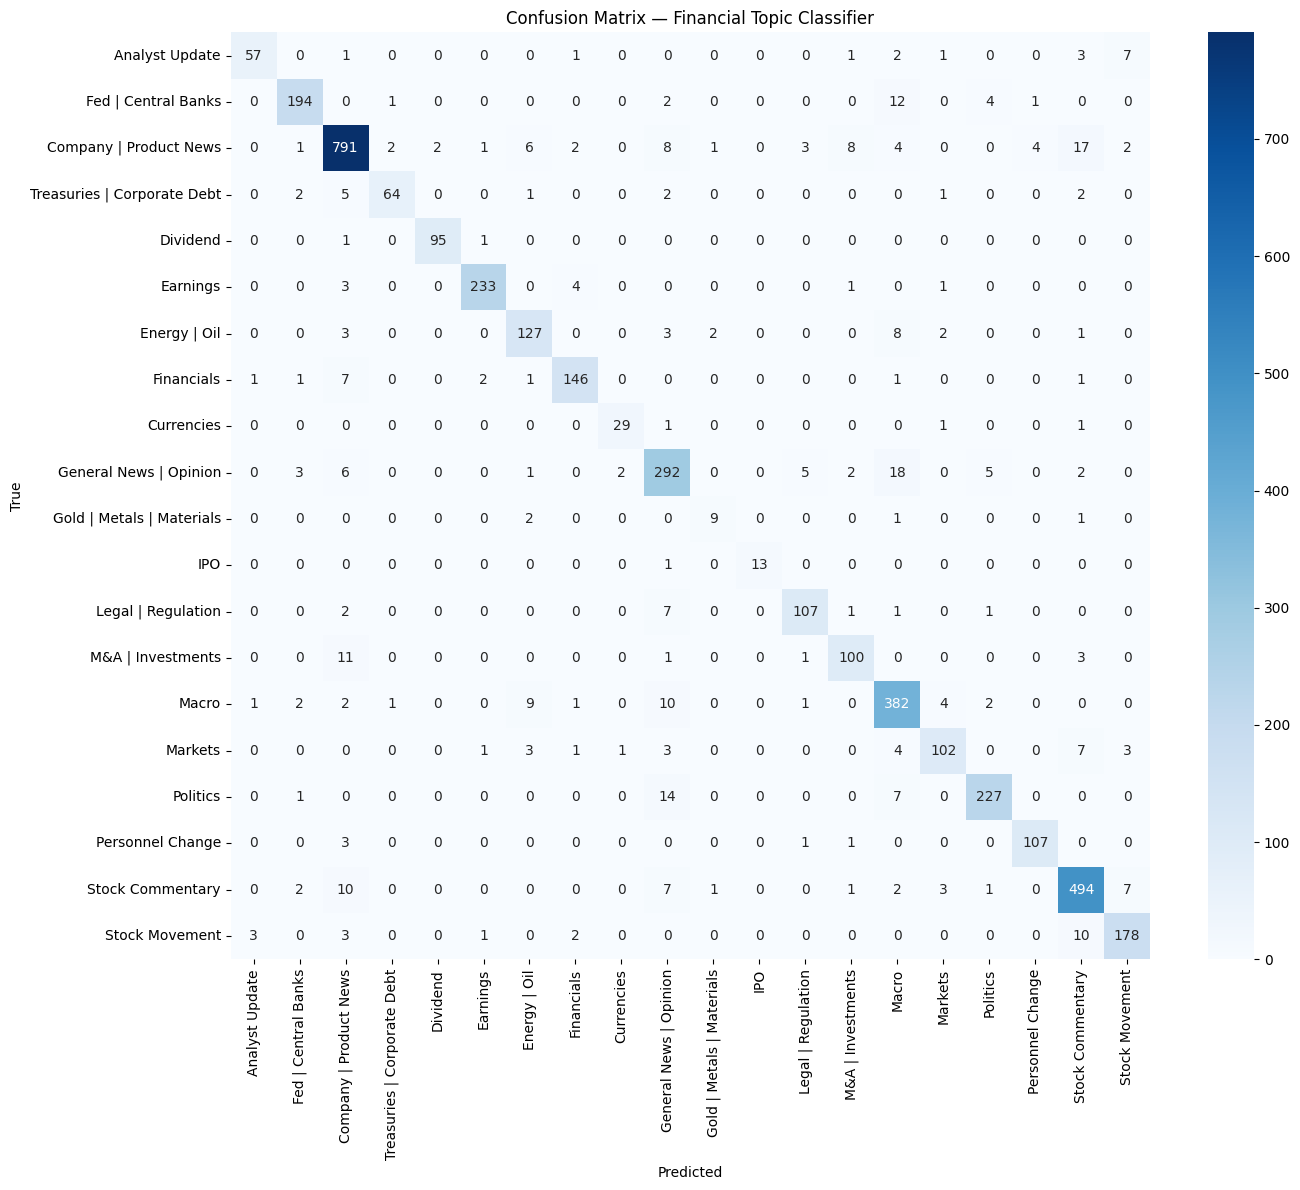

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=label_names, yticklabels=label_names, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.title("Confusion Matrix — Financial Topic Classifier")
plt.tight_layout()
plt.show()

## Step 7: Inference Function

A function that takes a single raw text string and returns the model's
predicted topic with a confidence score — this is the demoable piece of the
project, letting anyone test the classifier live on new text.

Uses identical tokenization settings to training (`max_length=96`,
`padding="max_length"`, `truncation=True`) to avoid train/inference mismatch.
`model.eval()` disables dropout for deterministic predictions.
`torch.no_grad()` skips gradient tracking since we're not training. Logits are
converted to probabilities via `softmax` so we can report a confidence score,
not just the raw predicted label.

In [41]:
import torch
import torch.nn.functional as F

def predict_topic(text):
    model.eval()
    
    inputs = tokenizer(
        text,
        padding="max_length",
        truncation=True,
        max_length=96,
        return_tensors="pt",
    )
    
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probs = F.softmax(logits, dim=-1)
    
    predicted_id = torch.argmax(probs, dim=-1).item()
    confidence = probs[0][predicted_id].item()
    
    return {
        "predicted_topic": label_names[predicted_id],
        "confidence": round(confidence, 4),
    }

In [42]:
print(predict_topic("Apple reports record quarterly earnings, beating analyst expectations"))
print(predict_topic("The Federal Reserve signaled it may pause rate hikes amid slowing inflation"))
print(predict_topic("MAIA Biotech files for a $15 million IPO on Nasdaq"))
print(predict_topic("Global markets react as trade tensions escalate between US and China"))

{'predicted_topic': 'Earnings', 'confidence': 0.9414}
{'predicted_topic': 'Fed | Central Banks', 'confidence': 1.0}
{'predicted_topic': 'IPO', 'confidence': 0.9961}
{'predicted_topic': 'Markets', 'confidence': 0.9922}


In [43]:
print(predict_topic("Central bank officials debate the broader economic outlook amid mixed signals"))

{'predicted_topic': 'Fed | Central Banks', 'confidence': 1.0}


## Step 8: Save the LoRA Adapter

So far the fine-tuned model only exists in this session's memory — once the Kaggle session ends, the trained weights are gone unless saved explicitly. `save_pretrained()` on a `peft`-wrapped model saves only the small LoRA adapter matrices (not the full ~1GB base model) — typically just a few MB. This is the artifact to commit to the project's GitHub repo or push to the Hugging Face Hub, and it's what `inference_example.py` loads on top of the base model.

In [44]:
ADAPTER_PATH = "./lora-financial-topic-classifier"

model.save_pretrained(ADAPTER_PATH)
tokenizer.save_pretrained(ADAPTER_PATH)

('./lora-financial-topic-classifier/tokenizer_config.json',
 './lora-financial-topic-classifier/chat_template.jinja',
 './lora-financial-topic-classifier/tokenizer.json')

Optional: push the adapter to the Hugging Face Hub instead of (or in addition to) saving locally, so it can be referenced by a repo ID rather than a local path:

```python
model.push_to_hub("your-hf-username/financial-topic-classifier-lora")
tokenizer.push_to_hub("your-hf-username/financial-topic-classifier-lora")
```